<div style="padding:28px 32px;border-radius:18px;background:linear-gradient(135deg,#071a1c 0%,#164e63 55%,#0f766e 100%);color:white;">
  <p style="margin:0;font-size:14px;letter-spacing:2px;color:#99f6e4;">SISTEMAS DE RECOMENDACIÓN · PROYECTO DE APLICACIÓN</p>
  <h1 style="margin:10px 0 8px;font-size:35px;">Recomendador de películas similares</h1>
  <p style="margin:0;font-size:18px;color:#ccfbf1;">Filtrado colaborativo basado en ítems con similitud del coseno</p>
  <p style="margin:18px 0 0;color:#a7f3d0;">Carlos Galán García</p>
</div>

## Introducción

En este proyecto vamos a construir un recomendador de películas similares a partir de las valoraciones de MovieLens. La intuición es sencilla: si dos películas reciben puntuaciones parecidas de los mismos usuarios, sus vectores de valoraciones también serán parecidos.

El notebook se centra en el motor item-item que pide el enunciado. Al final podremos buscar una película por su título o por su ID y obtener otras con un patrón de audiencia similar. Este motor también se ha integrado en la sección **Similares** de CineMatch, la aplicación web que reúne los distintos enfoques trabajados durante la asignatura. La web sirve como capa de uso; el notebook deja visible la preparación de datos, el cálculo y las decisiones metodológicas.

## 1. Preparación del entorno

Empezamos importando las librerías necesarias y dejando preparado el entorno. Todas están disponibles por defecto en Google Colab.

In [1]:
from pathlib import Path
import shutil
import ssl
import urllib.request
from urllib.error import URLError
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

sns.set_theme(style="whitegrid", context="notebook")
VERDE = "#0F766E"
CIAN = "#0891B2"
AZUL = "#4F46E5"
ROJO = "#EF4444"

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print("Entorno preparado correctamente.")

Entorno preparado correctamente.


## 2. Carga reproducible de MovieLens

Trabajaremos con `ml-latest-small`, una versión manejable de MovieLens con algo más de 100.000 valoraciones.

El notebook intenta descargar el ZIP desde la web oficial de GroupLens y reutiliza los archivos si ya existen. Si el entorno bloquea la descarga o da un error de certificado, ofrece una carga manual en Google Colab. Así mantenemos una ejecución cómoda sin desactivar la verificación de seguridad.

In [2]:
from pathlib import Path
import shutil
import urllib.request
from urllib.error import URLError
import zipfile

DATA_DIR = Path("data")
ZIP_PATH = DATA_DIR / "ml-latest-small.zip"
EXTRACTED_DIR = DATA_DIR / "ml-latest-small"
DATA_URL = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"


def cargar_zip_manualmente(destino):
    """Permite subir el ZIP si la descarga automática falla en Google Colab."""
    try:
        from google.colab import files
    except ImportError as error:
        raise RuntimeError(
            "No se ha podido descargar MovieLens. Descarga ml-latest-small.zip "
            "desde GroupLens y guárdalo en la carpeta data antes de continuar."
        ) from error

    print("Selecciona el archivo ml-latest-small.zip descargado desde GroupLens.")
    archivos = files.upload()
    if not archivos:
        raise RuntimeError("No se ha seleccionado ningún archivo.")

    nombre, contenido = next(iter(archivos.items()))
    if not nombre.lower().endswith(".zip"):
        raise ValueError("El archivo seleccionado no es un ZIP.")
    destino.write_bytes(contenido)


def preparar_movielens():
    DATA_DIR.mkdir(exist_ok=True)

    if (EXTRACTED_DIR / "ratings.csv").exists():
        print("MovieLens ya estaba preparado. Reutilizamos los archivos existentes.")
        return

    if not ZIP_PATH.exists():
        try:
            print("Descargando MovieLens latest-small desde GroupLens...")
            with urllib.request.urlopen(DATA_URL, timeout=60) as respuesta, open(ZIP_PATH, "wb") as archivo:
                shutil.copyfileobj(respuesta, archivo)
        except (URLError, TimeoutError, OSError) as error:
            print(f"La descarga automática no ha funcionado: {error}")
            cargar_zip_manualmente(ZIP_PATH)

    with zipfile.ZipFile(ZIP_PATH, "r") as archivo_zip:
        archivo_zip.extractall(DATA_DIR)


preparar_movielens()

ratings = pd.read_csv(EXTRACTED_DIR / "ratings.csv")
movies = pd.read_csv(EXTRACTED_DIR / "movies.csv")

print(f"Valoraciones: {len(ratings):,}")
print(f"Usuarios: {ratings['userId'].nunique():,}")
print(f"Películas valoradas: {ratings['movieId'].nunique():,}")
print(f"Escala: {ratings['rating'].min()} - {ratings['rating'].max()}")

movies.head()

MovieLens ya estaba preparado. Reutilizamos los archivos existentes.
Valoraciones: 100,836
Usuarios: 610
Películas valoradas: 9,724
Escala: 0.5 - 5.0


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


## 3. Exploración breve de los datos

Antes de construir el recomendador vamos a echar un vistazo rápido a las valoraciones y a la cantidad de información disponible para cada película.

Esto nos ayudará a evitar similitudes engañosas basadas únicamente en uno o dos usuarios.

,title,genres,valoracion_media,numero_valoraciones
314,Forrest Gump (1994),Comedy|Drama|Romance|War,4.1641,329
277,"Shawshank Redemption, The (1994)",Crime|Drama,4.4290,317
257,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,4.1971,307
510,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,4.1613,279
1938,"Matrix, The (1999)",Action|Sci-Fi|Thriller,4.1924,278
224,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,4.2311,251
418,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,3.7500,238
97,Braveheart (1995),Action|Drama|War,4.0316,237
507,Terminator 2: Judgment Day (1991),Action|Sci-Fi,3.9710,224
461,Schindler's List (1993),Drama|War,4.2250,220


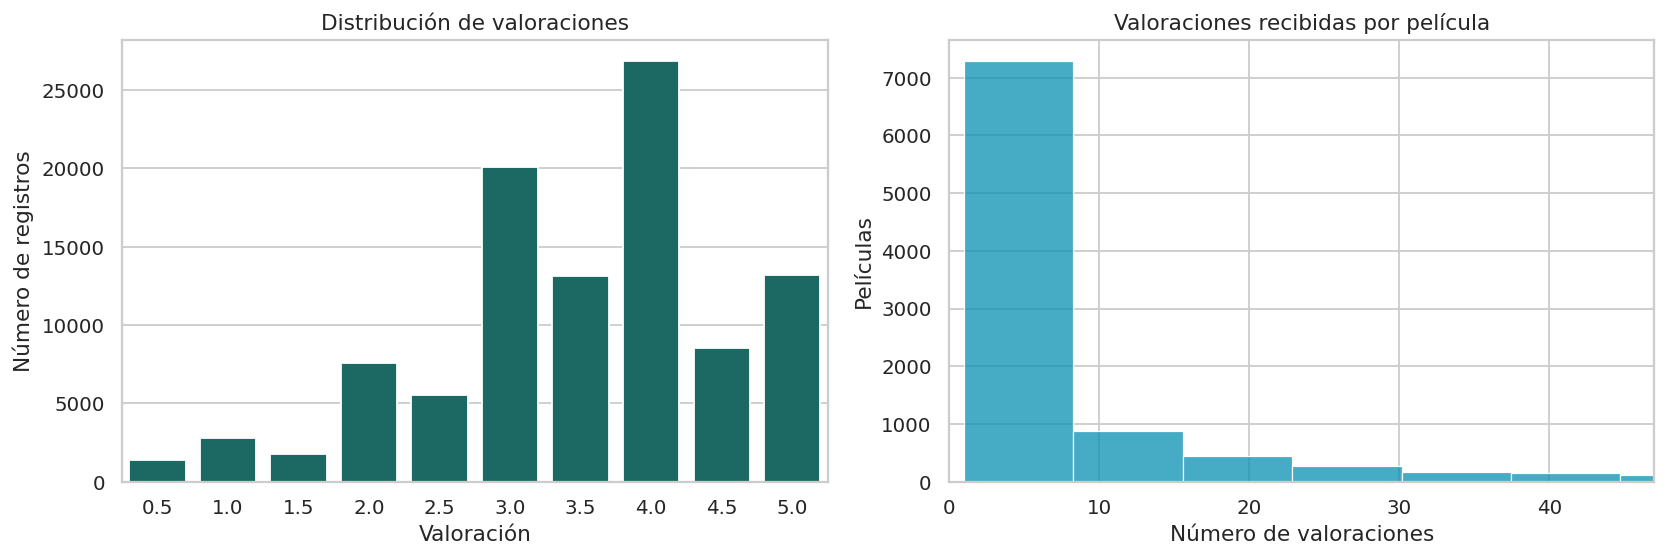

In [3]:
estadisticas_peliculas = (
    ratings.groupby("movieId")["rating"]
    .agg(valoracion_media="mean", numero_valoraciones="size")
    .reset_index()
    .merge(movies, on="movieId", how="left")
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.countplot(data=ratings, x="rating", color=VERDE, ax=axes[0])
axes[0].set_title("Distribución de valoraciones")
axes[0].set_xlabel("Valoración")
axes[0].set_ylabel("Número de registros")

sns.histplot(
    estadisticas_peliculas["numero_valoraciones"],
    bins=45, color=CIAN, ax=axes[1]
)
axes[1].set_title("Valoraciones recibidas por película")
axes[1].set_xlabel("Número de valoraciones")
axes[1].set_ylabel("Películas")
axes[1].set_xlim(0, estadisticas_peliculas["numero_valoraciones"].quantile(0.95))

plt.tight_layout()
plt.show()

estadisticas_peliculas[
    ["title", "genres", "valoracion_media", "numero_valoraciones"]
].sort_values("numero_valoraciones", ascending=False).head(10)

Vemos que unas pocas películas acumulan muchas valoraciones, mientras que gran parte del catálogo aparece muy pocas veces. Para trabajar con comparaciones algo más fiables, nos quedaremos con las películas que tengan al menos 20 valoraciones.

## 4. Construcción de la matriz usuario-película

Ahora organizamos las valoraciones en una matriz: cada fila representa a un usuario, cada columna una película y cada celda contiene la puntuación correspondiente.

Cuando un usuario no ha valorado una película aparece un cero. Ese cero significa que no tenemos información, no que la película le haya parecido malísima.

In [4]:
MIN_VALORACIONES = 20

peliculas_validas = estadisticas_peliculas.loc[
    estadisticas_peliculas["numero_valoraciones"] >= MIN_VALORACIONES,
    "movieId",
]

ratings_filtrado = ratings[ratings["movieId"].isin(peliculas_validas)].copy()

matriz_usuario_pelicula = ratings_filtrado.pivot_table(
    index="userId",
    columns="movieId",
    values="rating",
    fill_value=0,
)

print(f"Matriz completa conceptual: {ratings['userId'].nunique()} usuarios x {ratings['movieId'].nunique()} películas")
print(f"Matriz utilizada: {matriz_usuario_pelicula.shape[0]} usuarios x {matriz_usuario_pelicula.shape[1]} películas")
print(f"Mínimo de valoraciones por película: {MIN_VALORACIONES}")

matriz_usuario_pelicula.iloc[:5, :8]

Matriz completa conceptual: 610 usuarios x 9724 películas
Matriz utilizada: 610 usuarios x 1297 películas
Mínimo de valoraciones por película: 20


movieId,1,2,3,5,6,7,10,11
userId,,,,,,,,
1,4.0000,0.0000,4.0000,0.0000,4.0000,0.0000,0.0000,0.0000
2,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
4,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
5,4.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


## 5. Similitud del coseno entre películas

Para comparar películas transponemos la matriz. De este modo, cada película queda representada por un vector con las puntuaciones de todos los usuarios.

La similitud del coseno compara la dirección de dos vectores. Si dos películas suelen recibir puntuaciones altas y bajas de las mismas personas, el valor se acerca a 1. Si apenas comparten patrón, se acerca a 0. No es una probabilidad ni compara géneros, reparto o sinopsis.

Los ceros representan valoraciones desconocidas. Esta simplificación permite construir un motor claro y rápido, aunque también favorece a las películas populares que comparten más usuarios. Por eso filtramos antes las películas con muy pocas valoraciones y explicamos esta limitación al interpretar los resultados.

In [5]:
matriz_pelicula_usuario = matriz_usuario_pelicula.T

similitud = cosine_similarity(matriz_pelicula_usuario)

similitud_peliculas = pd.DataFrame(
    similitud,
    index=matriz_pelicula_usuario.index,
    columns=matriz_pelicula_usuario.index,
)

print(f"Matriz de similitud: {similitud_peliculas.shape[0]} x {similitud_peliculas.shape[1]}")
print(f"Similitud mínima observada: {similitud_peliculas.values.min():.3f}")
print(f"Similitud máxima observada: {similitud_peliculas.values.max():.3f}")

Matriz de similitud: 1297 x 1297
Similitud mínima observada: 0.000
Similitud máxima observada: 1.000


## 6. Función de recomendación

La función acepta un título, una parte del título o un ID de MovieLens. Primero localiza la película y después busca las que tengan el patrón de valoraciones más parecido.

También mostramos los géneros, la valoración media y el número de valoraciones para que el resultado sea más fácil de interpretar, aunque esos datos no intervienen en el orden.

In [6]:
catalogo_modelo = (
    movies[movies["movieId"].isin(matriz_pelicula_usuario.index)]
    .merge(
        estadisticas_peliculas[
            ["movieId", "valoracion_media", "numero_valoraciones"]
        ],
        on="movieId",
        how="left",
    )
    .set_index("movieId")
)


def resolver_pelicula(pelicula):
    # Localiza la película tanto si recibimos un ID como si recibimos un título.
    if isinstance(pelicula, (int, np.integer)):
        if pelicula not in catalogo_modelo.index:
            raise ValueError(
                "Ese ID no está disponible en el catálogo filtrado. "
                f"Se exigen al menos {MIN_VALORACIONES} valoraciones."
            )
        return int(pelicula)

    # Probamos primero una coincidencia exacta y después una búsqueda parcial.
    texto = str(pelicula).strip().lower()
    coincidencias_exactas = catalogo_modelo[
        catalogo_modelo["title"].str.lower() == texto
    ]
    if len(coincidencias_exactas) == 1:
        return int(coincidencias_exactas.index[0])

    coincidencias = catalogo_modelo[
        catalogo_modelo["title"].str.lower().str.contains(texto, regex=False)
    ]

    if len(coincidencias) == 1:
        return int(coincidencias.index[0])
    if len(coincidencias) == 0:
        raise ValueError("No se ha encontrado ninguna película con ese texto.")

    opciones = coincidencias["title"].head(10).tolist()
    raise ValueError(
        "La búsqueda no es única. Prueba con un título más concreto. "
        f"Coincidencias: {opciones}"
    )


def recomendar_peliculas(pelicula, n=10):
    # Recupera las n películas con el patrón de valoraciones más parecido.
    movie_id = resolver_pelicula(pelicula)

    # Quitamos la película consultada antes de seleccionar sus vecinas.
    scores = (
        similitud_peliculas.loc[movie_id]
        .drop(index=movie_id)
        .sort_values(ascending=False)
        .head(n)
        .rename("similitud")
    )

    resultado = (
        scores.to_frame()
        .join(catalogo_modelo)
        [["title", "genres", "similitud", "valoracion_media", "numero_valoraciones"]]
        .reset_index(names="movieId")
    )

    resultado.index = resultado.index + 1
    return resultado


print("Función creada correctamente.")

Función creada correctamente.


### Comprobación de la función

Antes de interpretar ejemplos concretos, comprobamos tres propiedades básicas: la película consultada no aparece entre sus propias recomendaciones, las similitudes están ordenadas y todos los valores quedan entre 0 y 1.

In [7]:
prueba = recomendar_peliculas("Toy Story (1995)", n=10)
id_toy_story = resolver_pelicula("Toy Story (1995)")

assert id_toy_story not in prueba["movieId"].tolist()
assert prueba["similitud"].is_monotonic_decreasing
assert prueba["similitud"].between(0, 1).all()

print("Comprobaciones superadas: exclusión, orden y rango de similitud correctos.")

Comprobaciones superadas: exclusión, orden y rango de similitud correctos.


## 7. Ejemplo de uso

Vamos a probar la función con `Toy Story (1995)`. Es una película muy conocida y con bastantes valoraciones, así que resulta un buen ejemplo para ver si las recomendaciones tienen sentido.

In [8]:
PELICULA_EJEMPLO = "Toy Story (1995)"

recomendaciones_toy_story = recomendar_peliculas(PELICULA_EJEMPLO, n=10)

print(f"Películas similares a {PELICULA_EJEMPLO}:")
recomendaciones_toy_story.round({
    "similitud": 3,
    "valoracion_media": 2,
})

Películas similares a Toy Story (1995):


,movieId,title,genres,similitud,valoracion_media,numero_valoraciones
1,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,0.5730,3.8600,97
2,480,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,0.5660,3.7500,238
3,780,Independence Day (a.k.a. ID4) (1996),Action|Adventure|Sci-Fi|Thriller,0.5640,3.4500,202
4,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,0.5570,4.2300,251
5,356,Forrest Gump (1994),Comedy|Drama|Romance|War,0.5470,4.1600,329
6,364,"Lion King, The (1994)",Adventure|Animation|Children|Drama|Musical|IMAX,0.5410,3.9400,172
7,1210,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Sci-Fi,0.5410,4.1400,196
8,648,Mission: Impossible (1996),Action|Adventure|Mystery|Thriller,0.5390,3.5400,162
9,1265,Groundhog Day (1993),Comedy|Fantasy|Romance,0.5340,3.9400,143
10,1270,Back to the Future (1985),Adventure|Comedy|Sci-Fi,0.5300,4.0400,171


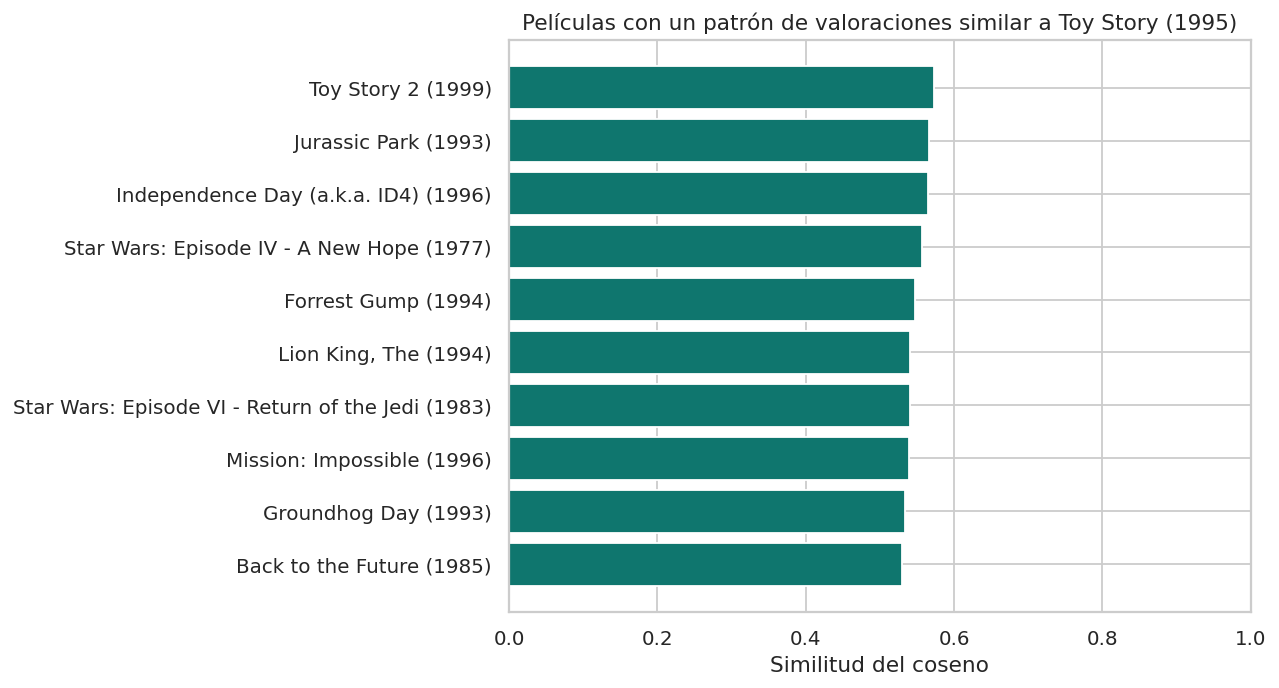

In [9]:
plt.figure(figsize=(10, 5.5))
orden = recomendaciones_toy_story.sort_values("similitud")
plt.barh(orden["title"], orden["similitud"], color=VERDE)
plt.xlabel("Similitud del coseno")
plt.ylabel("")
plt.title(f"Películas con un patrón de valoraciones similar a {PELICULA_EJEMPLO}")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

### Segundo ejemplo

Probamos también con `The Matrix`, una película bastante diferente. Así podemos ver cómo cambian las recomendaciones según el título de partida.

In [10]:
recomendaciones_matrix = recomendar_peliculas("Matrix, The (1999)", n=10)
recomendaciones_matrix.round({
    "similitud": 3,
    "valoracion_media": 2,
})

,movieId,title,genres,similitud,valoracion_media,numero_valoraciones
1,2959,Fight Club (1999),Action|Crime|Drama|Thriller,0.7140,4.2700,218
2,1196,Star Wars: Episode V - The Empire Strikes Back (1980),Action|Adventure|Sci-Fi,0.7010,4.2200,211
3,2028,Saving Private Ryan (1998),Action|Drama|War,0.6800,4.1500,188
4,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,0.6630,4.2300,251
5,1210,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Sci-Fi,0.6610,4.1400,196
6,4993,"Lord of the Rings: The Fellowship of the Ring, The (2001)",Adventure|Fantasy,0.6540,4.1100,198
7,2762,"Sixth Sense, The (1999)",Drama|Horror|Mystery,0.6510,3.8900,179
8,7153,"Lord of the Rings: The Return of the King, The (2003)",Action|Adventure|Drama|Fantasy,0.6400,4.1200,185
9,1198,Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981),Action|Adventure,0.6310,4.2100,200
10,3578,Gladiator (2000),Action|Adventure|Drama,0.6260,3.9400,170


Los resultados son bastante coherentes. Para `Toy Story` aparece primero `Toy Story 2`, mientras que para `The Matrix` encontramos títulos como `Fight Club` y varias películas de `Star Wars`.

Lo interesante es que el modelo no conoce los géneros para hacer estas recomendaciones: encuentra las relaciones únicamente a partir de las valoraciones de los usuarios.

## 8. De este motor a CineMatch

El notebook es la evidencia principal porque permite ver y ejecutar todo el proceso. CineMatch añade una capa de uso sobre estos cálculos: en la sección **Similares**, una persona puede buscar una película y consultar sus vecinas item-item sin trabajar directamente con la matriz.

La aplicación completa conserva también los enfoques de popularidad y recomendación personalizada trabajados en los casos anteriores. No los mezclamos aquí porque este proyecto tiene un objetivo más concreto: entender y construir bien el motor basado en ítems.

- Web: https://cine-match-primera-version-2026-08.vercel.app/
- Repositorio: https://github.com/carlosgalan01/CineMatch

Esta separación es intencionada. El notebook explica el método y permite reproducirlo; la web demuestra cómo se puede convertir en una función comprensible para una persona que solo quiere encontrar otra película.

## 9. Conclusiones

Hemos construido un recomendador item-item capaz de encontrar películas con patrones de audiencia parecidos. Los ejemplos de `Toy Story` y `The Matrix` muestran que, partiendo únicamente de las valoraciones, aparecen relaciones razonables y diferentes según la película de partida.

El mínimo de 20 valoraciones reduce comparaciones frágiles, aunque deja fuera títulos con poca información. La matriz también utiliza ceros para representar valoraciones desconocidas. Es una decisión sencilla y adecuada para este proyecto, pero no significa que el usuario haya valorado negativamente esas películas.

La función final permite consultar por título o ID, elimina la propia película, ordena las vecinas por similitud y añade contexto para interpretar el resultado. Como siguiente mejora compararía distintos mínimos de valoraciones y evaluaría el motor con una métrica offline. Para el objetivo actual, el resultado es reproducible, fácil de explicar y está conectado con una aplicación real mediante CineMatch.